In [1598]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import linear_model, preprocessing
from statsmodels.graphics.tsaplots import plot_acf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import learning_curve
import seaborn as sns

In [1599]:
fred = pd.read_csv('fred_tot.csv')
weather = pd.read_csv('weather.csv')

In [1600]:
def convert_letter(val):
    if isinstance(val, str): 
        val = val.strip().lower()
        try:
            if len(val) == 0: 
                return 0
            elif val == 'k':
                return 1_000
            elif val == 'm':
                return 1_000_000
            elif val == 'b':
                return 1_000_000_000
            elif val.endswith('k'):
                return int(float(val[:-1]) * 1_000)
            elif val.endswith('m'):
                return int(float(val[:-1]) * 1_000_000)
            elif val.endswith('b'):
                return int(float(val[:-1]) * 1_000_000_000)
            else:
                return float(val)
        except ValueError:
            return np.nan 
    elif isinstance(val, (int, float)):
        return val
    elif val is None:
        return np.nan
    else:
        return np.nan

In [1601]:
weather['Property Damage'] = weather['Property Damage'].apply(convert_letter)

In [1602]:
daily_summary = weather.groupby('observation_date').agg({
    'Property Damage': 'sum',
    'Total Injuries and Deaths': 'sum',
    'Event Type': 'count'
}).rename(columns={
    'Event Type': 'num_events'
})

In [1603]:
df = pd.merge(fred, daily_summary, on='observation_date', how='outer')
df.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS,Property Damage,Total Injuries and Deaths,num_events
0,1950-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3025000.0,7.0,4.0
1,1950-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2500.0,2.0,1.0
2,1950-01-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500000.0,5.0,2.0
3,1950-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,1.0
4,1950-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,550000.0,24.0,4.0


In [1604]:
full_range = pd.date_range(start=df['observation_date'].min(), end=df['observation_date'].max(), freq='D')
print(full_range.dtype)
print(df.index[:5])
print(full_range[:5])

datetime64[ns]
RangeIndex(start=0, stop=5, step=1)
DatetimeIndex(['1950-01-03', '1950-01-04', '1950-01-05', '1950-01-06',
               '1950-01-07'],
              dtype='datetime64[ns]', freq='D')


In [1605]:
df['observation_date'].dtypes

dtype('O')

In [1606]:
df['observation_date'] = pd.to_datetime(df['observation_date'])

In [1607]:
df['observation_date'].dtypes

dtype('<M8[ns]')

In [1608]:
df = df[df['observation_date'] >= '2015-10-01']

In [1609]:
df.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS,Property Damage,Total Injuries and Deaths,num_events
17284,2015-10-01,18892.206,272000.0,0.118627,5.0,1923.82,2.16,111.0439,0.12,2745.517,100.1563,1160.0,76.752,22.55,11161550.0,2.0,190.0
17285,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,20.94,25114500.0,3.0,112.0
17286,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,51188540.0,3.0,114.0
17287,2015-10-04,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,88252280.0,35.0,135.0
17288,2015-10-05,18892.206,267000.0,0.118627,5.0,1987.05,2.16,110.4445,0.12,2745.517,100.1563,1160.0,76.752,19.54,3582000.0,3.0,39.0


In [1610]:
df = df.reset_index(drop=True)
df.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS,Property Damage,Total Injuries and Deaths,num_events
0,2015-10-01,18892.206,272000.0,0.118627,5.0,1923.82,2.16,111.0439,0.12,2745.517,100.1563,1160.0,76.752,22.55,11161550.0,2.0,190.0
1,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,20.94,25114500.0,3.0,112.0
2,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,51188540.0,3.0,114.0
3,2015-10-04,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,100.1563,1160.0,76.752,NaN,88252280.0,35.0,135.0
4,2015-10-05,18892.206,267000.0,0.118627,5.0,1987.05,2.16,110.4445,0.12,2745.517,100.1563,1160.0,76.752,19.54,3582000.0,3.0,39.0


In [1611]:
df['flagged_event'] = ((df['Property Damage'] > 100000) & (df['num_events'] >= 1)).astype(int)

In [1612]:
df.isnull().sum()

observation_date                0
GDPC1                         570
ICSA                          570
Inflation                     570
UNRATE                        570
SP500                           0
DRCCLACBS                     204
DTWEXBGS                        6
FEDFUNDS                       53
IMPGS                         204
INDPRO                         53
PERMIT                         53
TCU                            53
VIXCLS                       1024
Property Damage              1396
Total Injuries and Deaths    1396
num_events                   1396
flagged_event                   0
dtype: int64

In [1613]:
df[['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']]= df[['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']].ffill()


In [1614]:
df[['Property Damage', 'Total Injuries and Deaths', 'num_events']] = df[['Property Damage', 'Total Injuries and Deaths', 'num_events']].fillna(0)

In [1615]:
df.isnull().sum()

C:\Users\Miranda\anaconda3\Lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


observation_date             0
GDPC1                        0
ICSA                         0
Inflation                    0
UNRATE                       0
SP500                        0
DRCCLACBS                    0
DTWEXBGS                     0
FEDFUNDS                     0
IMPGS                        0
INDPRO                       0
PERMIT                       0
TCU                          0
VIXCLS                       0
Property Damage              0
Total Injuries and Deaths    0
num_events                   0
flagged_event                0
dtype: int64

In [1616]:
df_pct = df[['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']].pct_change()
df_pct.head()

,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.000000,0.0,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
2,0.0,-0.018382,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.0,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858


In [1617]:
df_pct.head(15)

,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,INDPRO,PERMIT,TCU,VIXCLS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.000000,0.0,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
2,0.0,-0.018382,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.0,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858
5,0.0,0.000000,0.0,0.0,-0.003588,0.0,-0.002783,0.0,0.0,0.0,0.0,0.0,-0.007165
6,0.0,0.000000,0.0,0.0,0.008036,0.0,-0.002914,0.0,0.0,0.0,0.0,0.0,-0.051546
7,0.0,0.000000,0.0,0.0,0.008818,0.0,-0.001557,0.0,0.0,0.0,0.0,0.0,-0.053261
8,0.0,0.000000,0.0,0.0,0.000725,0.0,-0.005171,0.0,0.0,0.0,0.0,0.0,-0.019518
9,0.0,-0.007491,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


In [1618]:
df_pct['Inflation'].unique()

array([        nan,  0.        ,  9.63486191,  0.68844195,  0.1466935 ,
       -0.25807645, -0.31929283,  2.80829952,  0.70349941, -0.48563772,
       -0.283459  ])

This is good, I thought for a minute that it didn't load right. It just doesn't change until a later date. Lets merge this to our dataframe.

In [1620]:
df_pct['observation_date'] = df['observation_date']
cols = ['GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500', 'DRCCLACBS', 
                      'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU', 'VIXCLS']
df_pct = df_pct[cols].add_suffix("_pct")


In [1621]:
df_pct['observation_date'] = df['observation_date']

In [1622]:
df_pct.head()

,GDPC1_pct,ICSA_pct,Inflation_pct,UNRATE_pct,SP500_pct,DRCCLACBS_pct,DTWEXBGS_pct,FEDFUNDS_pct,IMPGS_pct,INDPRO_pct,PERMIT_pct,TCU_pct,VIXCLS_pct,observation_date
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-10-01
1,0.0,0.000000,0.0,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397,2015-10-02
2,0.0,-0.018382,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,2015-10-03
3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,2015-10-04
4,0.0,0.000000,0.0,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858,2015-10-05


In [1623]:
df2 = pd.merge(df, df_pct, on='observation_date', how='outer')

In [1624]:
df2.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,...,UNRATE_pct,SP500_pct,DRCCLACBS_pct,DTWEXBGS_pct,FEDFUNDS_pct,IMPGS_pct,INDPRO_pct,PERMIT_pct,TCU_pct,VIXCLS_pct
0,2015-10-01,18892.206,272000.0,0.118627,5.0,1923.82,2.16,111.0439,0.12,2745.517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
2,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,2015-10-04,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
4,2015-10-05,18892.206,267000.0,0.118627,5.0,1987.05,2.16,110.4445,0.12,2745.517,...,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858


In [1625]:
df2.columns

Index(['observation_date', 'GDPC1', 'ICSA', 'Inflation', 'UNRATE', 'SP500',
       'DRCCLACBS', 'DTWEXBGS', 'FEDFUNDS', 'IMPGS', 'INDPRO', 'PERMIT', 'TCU',
       'VIXCLS', 'Property Damage', 'Total Injuries and Deaths', 'num_events',
       'flagged_event', 'GDPC1_pct', 'ICSA_pct', 'Inflation_pct', 'UNRATE_pct',
       'SP500_pct', 'DRCCLACBS_pct', 'DTWEXBGS_pct', 'FEDFUNDS_pct',
       'IMPGS_pct', 'INDPRO_pct', 'PERMIT_pct', 'TCU_pct', 'VIXCLS_pct'],
      dtype='object')

In [1626]:
df2 = df2.dropna().reset_index(drop=True)


In [1627]:
df2.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,...,UNRATE_pct,SP500_pct,DRCCLACBS_pct,DTWEXBGS_pct,FEDFUNDS_pct,IMPGS_pct,INDPRO_pct,PERMIT_pct,TCU_pct,VIXCLS_pct
0,2015-10-02,18892.206,272000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.014315,0.0,-0.003092,0.0,0.0,0.0,0.0,0.0,-0.071397
1,2015-10-03,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2,2015-10-04,18892.206,267000.0,0.118627,5.0,1951.36,2.16,110.7006,0.12,2745.517,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,2015-10-05,18892.206,267000.0,0.118627,5.0,1987.05,2.16,110.4445,0.12,2745.517,...,0.0,0.018290,0.0,-0.002313,0.0,0.0,0.0,0.0,0.0,-0.066858
4,2015-10-06,18892.206,267000.0,0.118627,5.0,1979.92,2.16,110.1371,0.12,2745.517,...,0.0,-0.003588,0.0,-0.002783,0.0,0.0,0.0,0.0,0.0,-0.007165


In [1628]:
lags2 = [1, 7, 14]
for col in ['flagged_event']:  
    for lag in lags2:
        df2[f"{col}_lag{lag}"] = df2[col].shift(lag)

lags = [1, 7, 14]
for col in ['SP500_pct', 'GDPC1_pct', 'Inflation', 'UNRATE']:  
    for lag in lags2:
        df2[f"{col}_lag{lag}"] = df2[col].shift(lag)

In [1629]:
df2 = df2.dropna()
df2.head()

,observation_date,GDPC1,ICSA,Inflation,UNRATE,SP500,DRCCLACBS,DTWEXBGS,FEDFUNDS,IMPGS,...,SP500_pct_lag14,GDPC1_pct_lag1,GDPC1_pct_lag7,GDPC1_pct_lag14,Inflation_lag1,Inflation_lag7,Inflation_lag14,UNRATE_lag1,UNRATE_lag7,UNRATE_lag14
14,2015-10-16,18892.206,265000.0,0.118627,5.0,2033.11,2.16,108.9956,0.12,2745.517,...,0.014315,0.0,0.0,0.0,0.118627,0.118627,0.118627,5.0,5.0,5.0
15,2015-10-17,18892.206,264000.0,0.118627,5.0,2033.11,2.16,108.9956,0.12,2745.517,...,0.000000,0.0,0.0,0.0,0.118627,0.118627,0.118627,5.0,5.0,5.0
16,2015-10-18,18892.206,264000.0,0.118627,5.0,2033.11,2.16,108.9956,0.12,2745.517,...,0.000000,0.0,0.0,0.0,0.118627,0.118627,0.118627,5.0,5.0,5.0
17,2015-10-19,18892.206,264000.0,0.118627,5.0,2033.66,2.16,109.3858,0.12,2745.517,...,0.018290,0.0,0.0,0.0,0.118627,0.118627,0.118627,5.0,5.0,5.0
18,2015-10-20,18892.206,264000.0,0.118627,5.0,2030.77,2.16,109.3368,0.12,2745.517,...,-0.003588,0.0,0.0,0.0,0.118627,0.118627,0.118627,5.0,5.0,5.0


We are scaling the test and train separately to avoid leakage.

out of these ['GDPC1_pct', 'UNRATE_pct', 'SP500_pct', 'VIXCLS_pct'] we will be lookin gat sp500. 

In [1632]:
df2_reg = df2.copy()
df2_reg['SP500_pct_weekly'] = df2_reg['SP500_pct'].rolling(window=10).sum()
df2_reg.dropna(subset=['SP500_pct_weekly'], inplace=True)
df2_reg = df2_reg.drop('observation_date', axis=1)

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
X = df2_reg.drop('SP500_pct_weekly', axis=1)
y = df2_reg['SP500_pct_weekly']

train_size = int(len(df2_reg) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


results = []

In [1633]:
model1 = LinearRegression()
model1.fit(X_train, y_train) 
y_pred = model1.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Linear Regression",
    "Number": "1",
    "Target": "SP500", 
    "Window Size": "10",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.38458526767993273
MAE: 0.014519550394495904
MSE: 0.00038067549929156753
RMSE: 0.019510907187815934


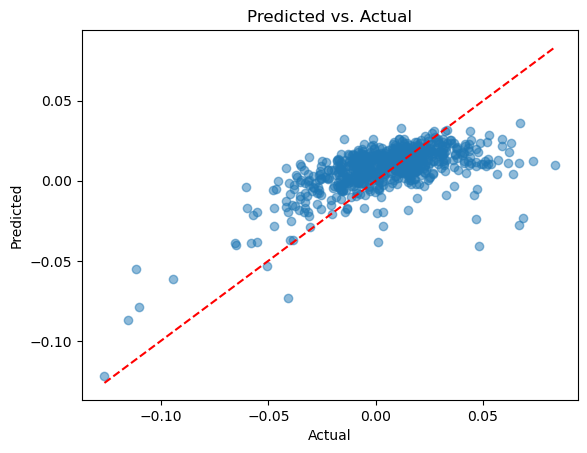

In [1634]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  
plt.show()

In [1635]:
model2 = RandomForestRegressor()
model2.fit(X_train, y_train) 
y_pred = model2.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Random Forest Regression",
    "Number": "2",
    "Target": "SP500", 
    "Window Size": "10",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.24412586371972378
MAE: 0.016064195551723753
MSE: 0.00046755910952165204
RMSE: 0.021623115166914595


In [1636]:
model3 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test) 
print(f'R Squared: {r2_score(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MSE: {mean_squared_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "XGBoost Regression",
    "Number": "3",
    "Target": "SP500", 
    "Window Size": "10",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.22362642092962937
MAE: 0.016277091578080397
MSE: 0.00048023939682952815
RMSE: 0.021914365079315625


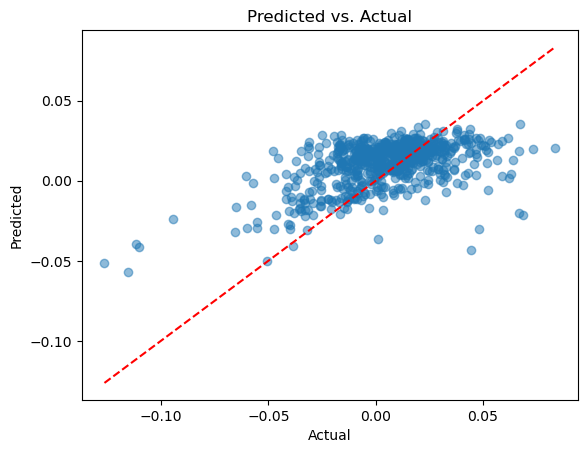

In [1637]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  
plt.show()

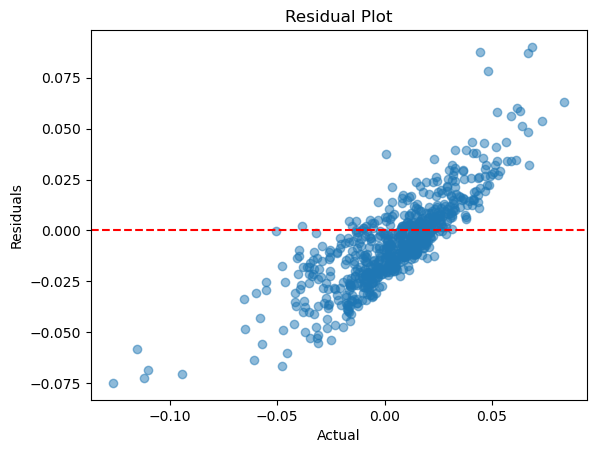

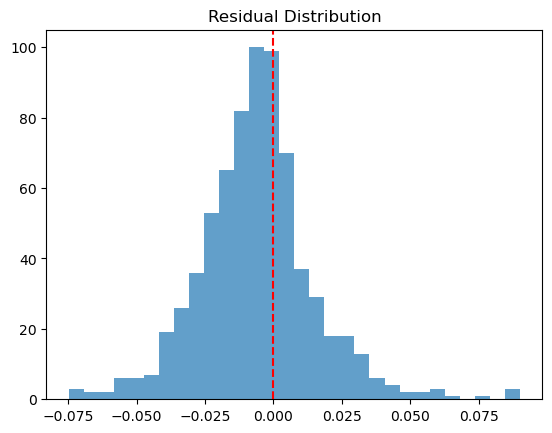

In [1638]:
residuals = y_test - y_pred

plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Histogram
plt.hist(residuals, bins=30, alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution")
plt.show()

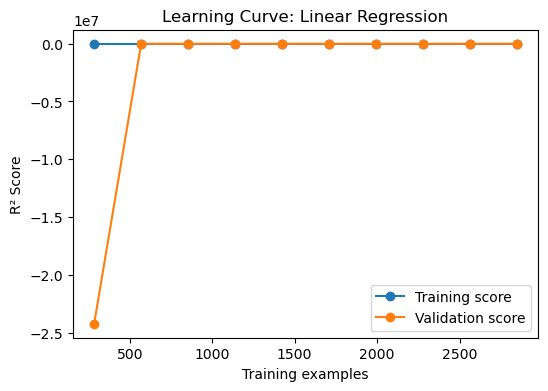

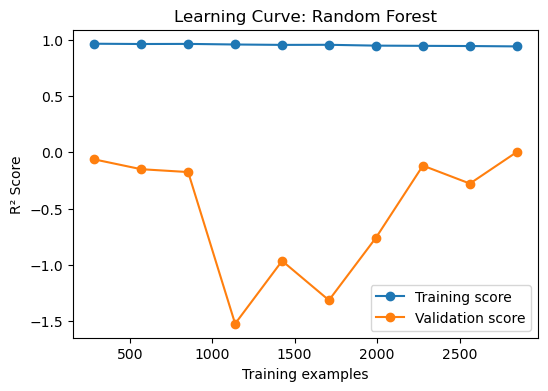

In [1639]:
models = {
    "Linear Regression": model1,
    "Random Forest": model2
}

for name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring="r2", 
        train_sizes=np.linspace(0.1, 1.0, 10), 
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, 'o-', label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', label="Validation score")
    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Training examples")
    plt.ylabel("R² Score")
    plt.legend()

Lets try different window sizes for our target

In [1641]:
df2_reg['SP500_pct_weekly'] = df2_reg['SP500_pct'].rolling(window=15).sum()

In [1642]:
model4 = LinearRegression()
model4.fit(X_train, y_train) 
y_pred = model4.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

results.append({
    "Model": "Linear Regression",
    "Number": "4",
    "Target": "SP500", 
    "Window Size": "15",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.38458526767993273
MAE: 0.014519550394495904
MSE: 0.00038067549929156753
RMSE: 0.019510907187815934


In [1643]:
model5 = RandomForestRegressor()
model5.fit(X_train, y_train) 
y_pred = model5.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Random Forest Regression",
    "Number": "5",
    "Target": "SP500", 
    "Window Size": "15",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.2594292210990867
MAE: 0.016047214267721842
MSE: 0.0004580929513273817
RMSE: 0.02140310611400555


In [1644]:
model6 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model6.fit(X_train, y_train)
y_pred = model6.predict(X_test) 
print(f'R Squared: {r2_score(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MSE: {mean_squared_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "XGBoost Regression",
    "Number": "6",
    "Target": "SP500", 
    "Window Size": "15",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.22362642092962937
MAE: 0.016277091578080397
MSE: 0.00048023939682952815
RMSE: 0.021914365079315625


In [1645]:
df2_reg['SP500_pct_weekly'] = df2_reg['SP500_pct'].rolling(window=8).sum()

In [1646]:
model7 = LinearRegression()
model7.fit(X_train, y_train) 
y_pred = model7.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Linear Regression",
    "Number": "7",
    "Target": "SP500", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.38458526767993273
MAE: 0.014519550394495904
MSE: 0.00038067549929156753
RMSE: 0.019510907187815934


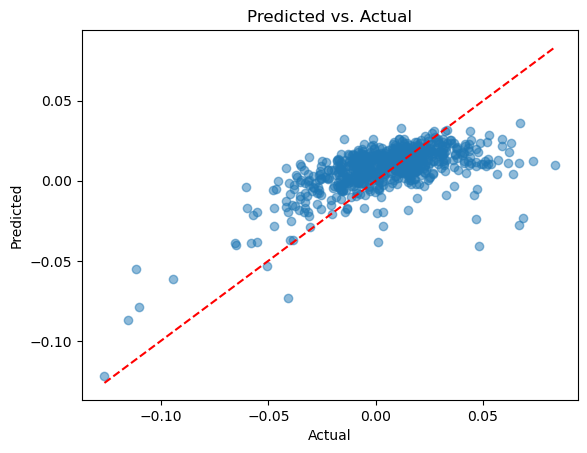

In [1647]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs. Actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  
plt.show()

In [1648]:
model8= RandomForestRegressor()
model8.fit(X_train, y_train) 
y_pred = model8.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Random Forest Regression",
    "Number": "8",
    "Target": "SP500", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.2630354219172323
MAE: 0.015722098974679098
MSE: 0.00045586227301420924
RMSE: 0.021350931432005706


In [1649]:
model9 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model9.fit(X_train, y_train)
y_pred = model9.predict(X_test) 
print(f'R Squared: {r2_score(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MSE: {mean_squared_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "XGBoost Regression",
    "Number": "9",
    "Target": "SP500", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.22362642092962937
MAE: 0.016277091578080397
MSE: 0.00048023939682952815
RMSE: 0.021914365079315625


A window size of 8 seems to be the best. 

In [1651]:
df2_reg_2 = df2.copy()
df2_reg_2['VIXCLS_pct_weekly'] = df2_reg_2['VIXCLS_pct'].rolling(window=8).sum()
df2_reg_2.dropna(subset=['VIXCLS_pct_weekly'], inplace=True)
df2_reg = df2_reg_2.drop('observation_date', axis=1)

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
X = df2_reg.drop('VIXCLS_pct_weekly', axis=1)
y = df2_reg['VIXCLS_pct_weekly']

train_size = int(len(df2_reg_2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [1652]:
model10 = LinearRegression()
model10.fit(X_train, y_train) 
y_pred = model10.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Linear Regression",
    "Number": "10",
    "Target": "VIXCLS", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -1.76513873969549
MAE: 0.26051500872487104
MSE: 0.10397559759890097
RMSE: 0.3224524733955393


In [1653]:
model11= RandomForestRegressor()
model11.fit(X_train, y_train) 
y_pred = model11.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Random Forest Regression",
    "Number": "11",
    "Target": "VIXCLS", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.3244706242152502
MAE: 0.114022192032137
MSE: 0.025401463418275677
RMSE: 0.1593783655904266


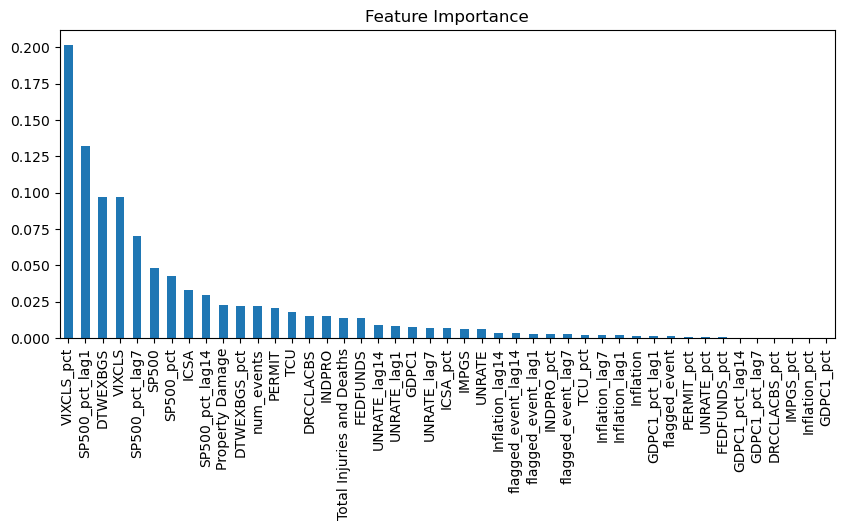

In [1654]:
importances = model11.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind="bar", figsize=(10,4))
plt.title("Feature Importance")
plt.show()

In [1655]:
model12 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model12.fit(X_train, y_train)
y_pred = model12.predict(X_test) 
print(f'R Squared: {r2_score(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MSE: {mean_squared_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "XGBoost Regression",
    "Number": "12",
    "Target": "VIXCLS", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: 0.29476399367001227
MAE: 0.1210441819211192
MSE: 0.02651850127943234
RMSE: 0.16284502227403927


Random Forest does well better with the target being 'VIXCLS' rather than 'SP500'

In [1657]:
df2_reg_2 = df2.copy()
df2_reg_2['UNRATE_pct_weekly'] = df2_reg_2['UNRATE_pct'].rolling(window=8).sum()
df2_reg_2.dropna(subset=['UNRATE_pct_weekly'], inplace=True)
df2_reg = df2_reg_2.drop('observation_date', axis=1)

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
X = df2_reg.drop('UNRATE_pct_weekly', axis=1)
y = df2_reg['UNRATE_pct_weekly']

train_size = int(len(df2_reg_2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [1658]:
model13 = LinearRegression()
model13.fit(X_train, y_train) 
y_pred = model13.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Linear Regression",
    "Number": "13",
    "Target": "UNRATE", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -1.0816338805741075
MAE: 0.009265303081773648
MSE: 0.0001278928879370526
RMSE: 0.011308973779130121


In [1659]:
model14= RandomForestRegressor()
model14.fit(X_train, y_train) 
y_pred = model14.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Random Forest Regression",
    "Number": "14",
    "Target": "UNRATE", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -4.553160069542795
MAE: 0.015179468942143478
MSE: 0.00034117895807627736
RMSE: 0.018471030238627117


In [1660]:
model15 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model15.fit(X_train, y_train)
y_pred = model15.predict(X_test) 
print(f'R Squared: {r2_score(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MSE: {mean_squared_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "XGBoost Regression",
    "Number": "15",
    "Target": "UNRATE", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -0.2865078037935014
MAE: 0.006268086799399346
MSE: 7.904137222023294e-05
RMSE: 0.00889052148190605


Our models are not good at predicting "UNRATE"

In [1662]:
df2_reg_2 = df2.copy()
df2_reg_2['GDPC1_pct_weekly'] = df2_reg_2['GDPC1_pct'].rolling(window=8).sum()
df2_reg_2.dropna(subset=['GDPC1_pct_weekly'], inplace=True)
df2_reg = df2_reg_2.drop('observation_date', axis=1)

ignore_cols = ['flagged_event', 'flagged_event_lag1', 'flagged_event_lag7', 'flagged_event_lag14']
X = df2_reg.drop('GDPC1_pct_weekly', axis=1)
y = df2_reg['GDPC1_pct_weekly']

train_size = int(len(df2_reg_2) * 0.8)
X_train, X_test = X.iloc[:train_size].copy(), X.iloc[train_size:].copy()
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaled_cols = [c for c in X.columns if c not in ignore_cols]
scaler = StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [1663]:
model16 = LinearRegression()
model16.fit(X_train, y_train) 
y_pred = model16.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "Linear Regression",
    "Number": "16",
    "Target": "GDP", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -3.0680372051618727
MAE: 0.0014851667372932592
MSE: 3.5140883275840013e-06
RMSE: 0.0018745901759008557


In [1664]:
model17= RandomForestRegressor()
model17.fit(X_train, y_train) 
y_pred = model17.predict(X_test) 

print(f'R Squared: {r2_score(y_test, y_pred)}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred)}') 
print(f'MSE: {mean_squared_error(y_test, y_pred)}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

results.append({
    "Model": "Random Forest Regression",
    "Number": "17",
    "Target": "GDP", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -2.9567695713954114
MAE: 0.0016554612548745251
MSE: 3.417972123789092e-06
RMSE: 0.0018487758446575106


In [1665]:
model18 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model18.fit(X_train, y_train)
y_pred = model18.predict(X_test) 
print(f'R Squared: {r2_score(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MAE: {mean_absolute_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'MSE: {mean_squared_error(y_test, y_pred, multioutput="uniform_average")}') 
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}') 

results.append({
    "Model": "XGBoost Regression",
    "Number": "18",
    "Target": "GDP", 
    "Window Size": "8",
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
})


R Squared: -0.6743428256654909
MAE: 0.0010173607413551714
MSE: 1.446345813302608e-06
RMSE: 0.0012026411822745004


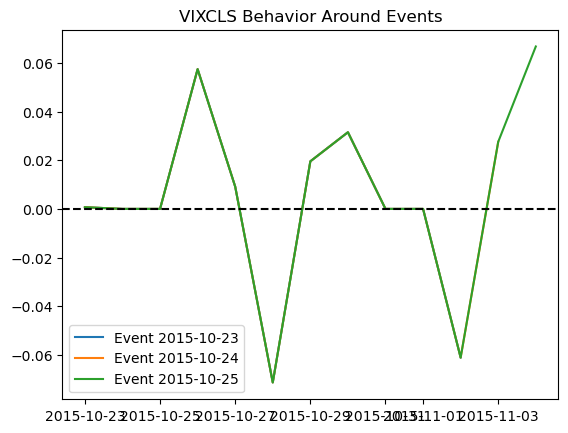

In [1666]:
event_dates = df2_reg_2.loc[df2_reg_2['flagged_event'] == 1, 'observation_date']

window = 10

for event_date in event_dates[:3]:
    event_window = df2_reg_2[(df2_reg_2['observation_date'] >= event_date - pd.Timedelta(days=window)) &
                    (df2_reg_2['observation_date'] <= event_date + pd.Timedelta(days=window))]
    plt.plot(event_window['observation_date'], event_window['VIXCLS_pct'], label=f'Event {event_date.date()}')
plt.axhline(0, color="black", linestyle="--")
plt.legend()
plt.title("VIXCLS Behavior Around Events")
plt.show()

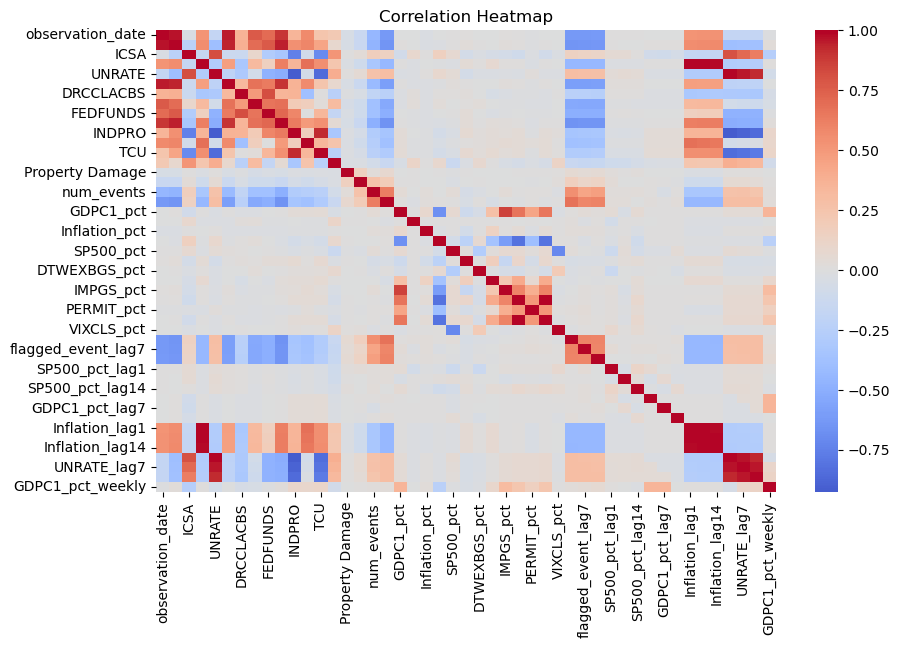

In [1667]:
plt.figure(figsize=(10,6))
sns.heatmap(df2_reg_2.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows some feature relationships we should explore. 

In [1669]:
results_df = pd.DataFrame(results)

In [1670]:
results_df.head()

,Model,Number,Target,Window Size,R2,MAE,MSE,RMSE
0,Linear Regression,1,SP500,10,0.384585,0.014520,0.000381,0.019511
1,Random Forest Regression,2,SP500,10,0.244126,0.016064,0.000468,0.021623
2,XGBoost Regression,3,SP500,10,0.223626,0.016277,0.000480,0.021914
3,Linear Regression,4,SP500,15,0.384585,0.014520,0.000381,0.019511
4,Random Forest Regression,5,SP500,15,0.259429,0.016047,0.000458,0.021403


In [1671]:
ordered_results = results_df.sort_values(by="R2", ascending=False)


In [1672]:
ordered_results.head()

,Model,Number,Target,Window Size,R2,MAE,MSE,RMSE
0,Linear Regression,1,SP500,10,0.384585,0.014520,0.000381,0.019511
3,Linear Regression,4,SP500,15,0.384585,0.014520,0.000381,0.019511
6,Linear Regression,7,SP500,8,0.384585,0.014520,0.000381,0.019511
10,Random Forest Regression,11,VIXCLS,8,0.324471,0.114022,0.025401,0.159378
11,XGBoost Regression,12,VIXCLS,8,0.294764,0.121044,0.026519,0.162845
